# Import libraries

In [107]:
import numpy as np
import pandas as pd
import re
import ssl
import nltk
import matplotlib.pyplot as plt

# Load CSVs from the /data directory

In [108]:
df_train = pd.read_csv('../data/train.csv')
df_test = pd.read_csv('../data/test.csv')

# Preview structure


In [109]:
df_train.head()
df_test.head()

,id,review,label
0,0,Once again Mr. Costner has dragged out a movie...,0
1,1,This is an example of why the majority of acti...,0
2,2,"First of all I hate those moronic rappers, who...",0
3,3,Not even the Beatles could write songs everyon...,0
4,4,Brass pictures (movies is not a fitting word f...,0


# Check Data Attributes and Types

In [110]:
print(df_train.info())

print(df_train['label'].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 75000 entries, 0 to 74999
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      75000 non-null  int64 
 1   review  75000 non-null  object
 2   label   75000 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 1.7+ MB
None
label
-1    50000
 0    12500
 1    12500
Name: count, dtype: int64


# Check for Missing Values and Quality Issues

In [111]:
# Null/missing values
print("Missing values (train):")
print(df_train.isnull().sum())

print("Missing values (test):")
print(df_test.isnull().sum())


Missing values (train):
id        0
review    0
label     0
dtype: int64
Missing values (test):
id        0
review    0
label     0
dtype: int64


There are no missing values in either train or test datasets.
All rows contain valid IDs, reviews, and labels.

=> Don’t need to drop or impute any data at this stage

In [112]:
# Check review length distribution
df_train['review_length'] = df_train['review'].apply(lambda x: len(str(x).split()))
df_train['review_length'].describe()

count    75000.00000
mean       234.21816
std        173.75620
min          9.00000
25%        127.00000
50%        175.00000
75%        285.00000
max       2470.00000
Name: review_length, dtype: float64

Most reviews are between 127–285 words (Q1–Q3).

Mean = 234, Max = 2470 → right-skewed distribution.

# Check for Duplicate Values

In [113]:
# Checking for duplicate values
# training 
print("Number of rows before removing duplicates (train):", len(df_train))
df_train.drop_duplicates(inplace=True)
print("Number of rows after removing duplicates (train):", len(df_train))

# test 
print("Number of rows before removing duplicates (test):", len(df_test))
df_train.drop_duplicates(inplace=True)
print("Number of rows after removing duplicates (test):", len(df_test))


Number of rows before removing duplicates (train): 75000
Number of rows after removing duplicates (train): 75000
Number of rows before removing duplicates (test): 25000
Number of rows after removing duplicates (test): 25000


As a result, we know that there are no duplicate values exist in those DataFrames.

# Text Preprocessing

In [114]:
# Covert the text to lowercase.
# Remove the punctuation

def preprocess_text(text):
    # Convert to lowercase
    text = text.lower()
    # Remove punctuation using regex
    text = re.sub(r'[^\w\s]', '', text)
    return text

df_train['review'] = df_train['review'].apply(preprocess_text)
df_test['review'] = df_test['review'].apply(preprocess_text)

After preproccesing, the datasets don't contain any uppercase letters and punctuation.

# Eliminate stopwords and apply stemming or lemmatization

In [115]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Stopwords list
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

# Build function
def tokenizer(text):
    tokens = re.findall(r'\b\w+\b', text.lower())
    tokens = [word for word in tokens if word not in ENGLISH_STOP_WORDS]
    return tokens

# Apply to dataset
df_train['tokens'] = df_train['review'].apply(tokenizer)
df_test['tokens'] = df_test['review'].apply(tokenizer)

# Display results
df_train[['review', 'tokens']].head()


,review,tokens
0,story of a man who has unnatural feelings for ...,"[story, man, unnatural, feelings, pig, starts,..."
1,airport 77 starts as a brand new luxury 747 pl...,"[airport, 77, starts, brand, new, luxury, 747,..."
2,this film lacked something i couldnt put my fi...,"[film, lacked, finger, charisma, leading, actr..."
3,sorry everyone i know this is supposed to be a...,"[sorry, know, supposed, art, film, wow, handed..."
4,when i was little my parents took me along to ...,"[little, parents, took, theater, interiors, mo..."


# Visualize class distributions (positive vs. negative reviews)

### Use sentiment analysis to differentiate the reviews with label -1 are postive (1) or negative (0)

In [116]:
# Download the vander_lexicon package for sentiment analusis
# Temporarily disable SSL certificate verification in case download problem
try:
    _create_unverified_https_context = ssl._create_unverified_context
except AttributeError:
# If the older version of Python doesn't support unverified contexts
    pass
else:
    ssl._create_default_https_context = _create_unverified_https_context
nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /Users/kaihsinhung/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [117]:
from nltk.sentiment.vader import SentimentIntensityAnalyzer
train_sentiment_analyzer = SentimentIntensityAnalyzer()

# classify sentiment
def classify_sentiment(text):
    scores = train_sentiment_analyzer.polarity_scores(text)
    compound = scores['compound']
    # negative label = 0
    # positive lable = 1
    if compound >= 0:
        return 1
    else:
        return 0    

In [ ]:
# Apply classification with the label equal to -1 (unsup)
# It will takes few minutes to run
mask = df_train['label'] == -1
df_train.loc[mask, 'label'] = df_train.loc[mask, 'review'].apply(classify_sentiment)

In [119]:
df_train['label'].value_counts()

label
1    44991
0    30009
Name: count, dtype: int64

As a result, we can see there is no more review with label = -1

### Visualization

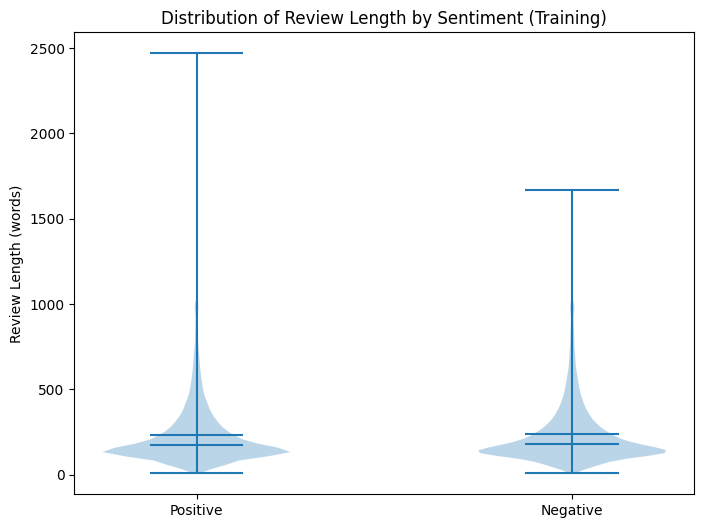

In [125]:
# positive = 1, negative = 0
df_train_positive = df_train[df_train['label'] == 1]['review_length']
df_train_negative = df_train[df_train['label'] == 0]['review_length']

# Combine data into a list
list_train_visualization = [df_train_positive, df_train_negative]

# Create the violin plot
fig, ax = plt.subplots(figsize=(8, 6))
parts = ax.violinplot(list_train_visualization, showmeans=True, showmedians=True)

# Set custom x-tick labels
ax.set_xticks([1, 2])
ax.set_xticklabels(['Positive', 'Negative'])

# Add labels and title
ax.set_ylabel('Review Length (words)')
ax.set_title('Distribution of Review Length by Sentiment (Training)')

plt.show()

As result we can see that:
- Postive reviews have a wider range, extending up to 2500 words compare to Negative only have closely 1500 words.

- According with median we can see each sentiment has almost same distribution.

- Some positive reviewers tends to write very long reivews.
